In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df_copy = df.drop(['day','month','year'],axis=1)#drop day month year
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [5]:
df_copy['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [6]:
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [7]:
df['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [8]:
X = df_copy.drop('FWI',axis = 1)
y = df_copy['FWI']

In [9]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [10]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [11]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

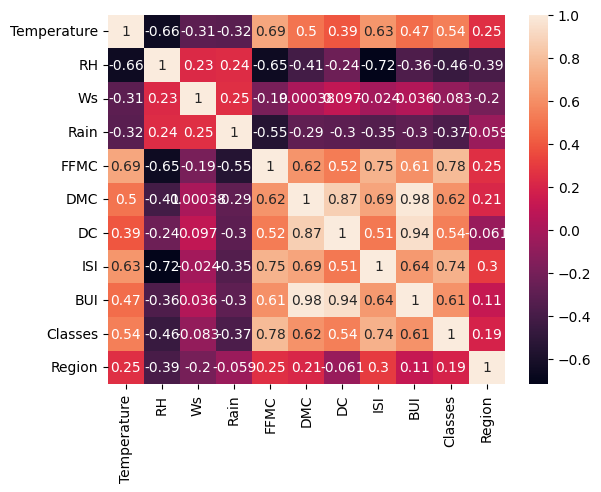

In [12]:
#check for multicolinearity
sns.heatmap(X_train.corr(),annot=True)

In [13]:
def correlation(dataset,threshold):
  cor_col = set()
  corr_matrix = dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j]>threshold):
        colname = corr_matrix.columns[i]
        cor_col.add(colname)
  return cor_col
correlation(X_train,0.80)

{'BUI', 'DC'}

In [14]:
#standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

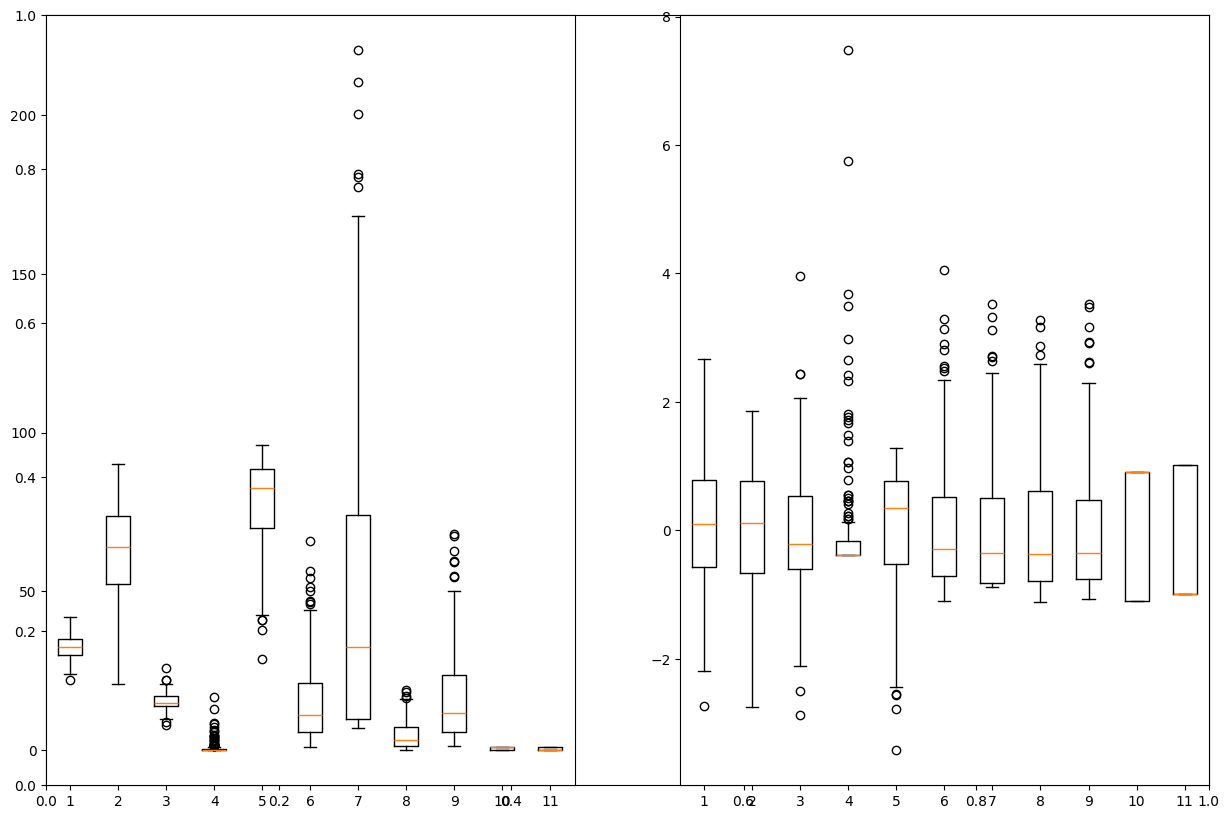

In [15]:
#to visualize outliers between x_train and x_train_scaled
plt.subplots(figsize =(15,10))
plt.subplot(1,2,1)
plt.boxplot(X_train)
plt.subplot(1,2,2)
plt.boxplot(x_train_scaled)
plt.show()

0.4698243571688517
0.9893850294922101


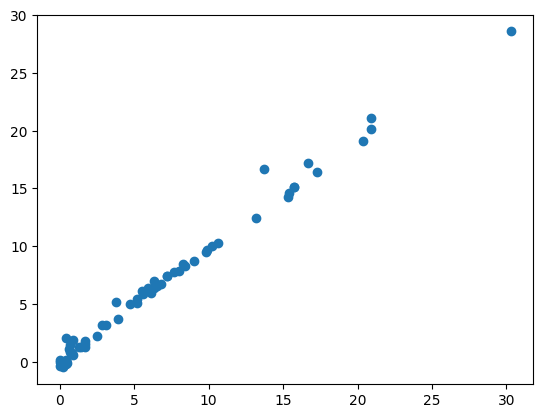

In [16]:
#Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_scaled,y_train)
from sklearn.metrics import mean_squared_error,r2_score
y_pred = lr.predict(X_test_scaled)
print(mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
print(r2_score(y_test,y_pred))

2.000058348289227
0.9548117077009715


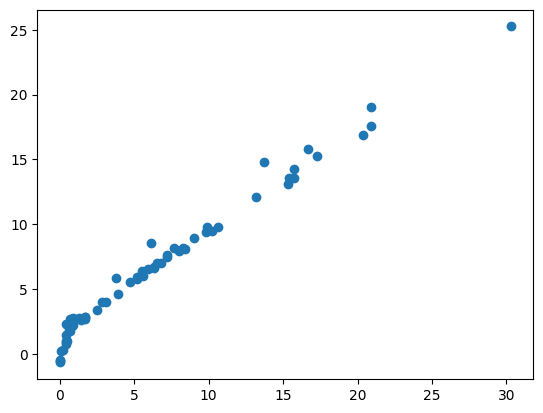

In [19]:
#Lasso Regression
# Linear Regression with regularization, It is used to: feature selection(automatically removes irrelevent features),reduce overfitting, select important features automatically
from sklearn import linear_model
lasso = linear_model.Lasso()
lasso.fit(x_train_scaled,y_train)
from sklearn.metrics import mean_squared_error,r2_score
y_pred = lasso.predict(X_test_scaled)
print(mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.5677317795293595
0.9871729594175267


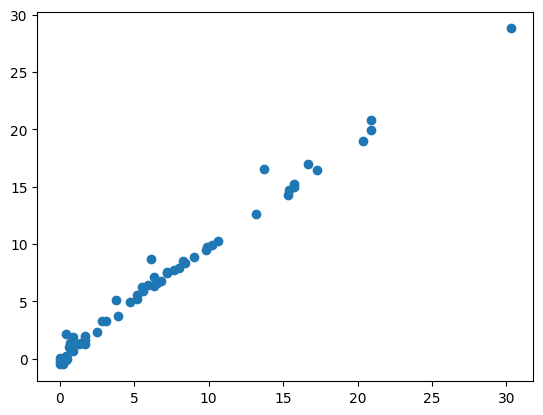

In [22]:
#ridge regression: Ridge Regression is a type of Linear Regression with L2 regularization
# It helps:
# reduce overfitting
# stabilize the model
# ---------Add pelalty term to control weight Loss=MSE+λ∑w2, what does penalty do is
# 👉 It shrinks weights
# Reduces magnitude of coefficients
# Keeps all features (does NOT remove them)
from sklearn.linear_model import Ridge
ridge = linear_model.Ridge()
ridge.fit(x_train_scaled,y_train)
from sklearn.metrics import mean_squared_error,r2_score
y_pred = ridge.predict(X_test_scaled)
print(mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
print(r2_score(y_test,y_pred))

4.396320516000338
0.900671789556956


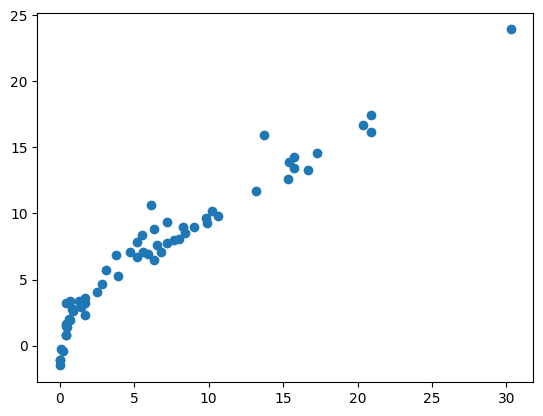

In [23]:
#Elastic net : to reduce problems of ridge and lasso rigression
# problem with lasso: struggle with correlated features, if two features are highly related then it will pick one and drop other
# problem with ridge: no featue selection, keeps all the features even useless one also remain
# Loss=MSE+λ1​∑∣w∣+λ2​∑w2, feature selection like lasso, handle multicolinearity like ridge
from sklearn.linear_model import ElasticNet
elasticnet = linear_model.ElasticNet()
elasticnet.fit(x_train_scaled,y_train)
from sklearn.metrics import mean_squared_error,r2_score
y_pred = elasticnet.predict(X_test_scaled)
print(mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.5599752461373918
0.9873482065539132


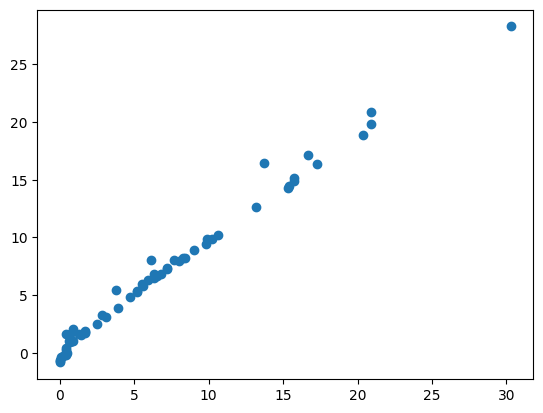

In [24]:
#LassoCV for cross validation
from sklearn.linear_model import LassoCV
lcv = linear_model.LassoCV(cv=5)
lcv.fit(x_train_scaled,y_train)
from sklearn.metrics import mean_squared_error,r2_score
y_pred = lcv.predict(X_test_scaled)
print(mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
print(r2_score(y_test,y_pred))

0.5677317795293595
0.9871729594175267


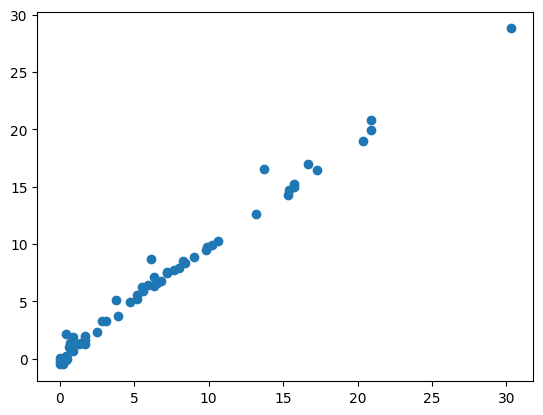

In [25]:
#RidgeCV for cross validation
from sklearn.linear_model import RidgeCV
rcv = linear_model.RidgeCV(cv=5)
rcv.fit(x_train_scaled,y_train)
from sklearn.metrics import mean_squared_error,r2_score
y_pred = rcv.predict(X_test_scaled)
print(mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
print(r2_score(y_test,y_pred))

In [26]:
#pickle the machine learning model, preprocessing model standardscaler
#Pickling in Python refers to the process of serializing an object into a byte stream, which can then be stored in a file or transmitted over a network. The reverse process, called unpickling, reconstructs the original object from the byte stream. The pickle module in Python provides the functionality for pickling and unpickling objects.
#Pickling is useful for saving and loading complex data structures, preserving program states, and sharing objects between processes. It supports most built-in Python objects, including lists, dictionaries, tuples, and custom class instances. However, it's important to note that the pickle module is not secure against maliciously constructed data and should only be used with trusted sources.
ridge

Ridge()

In [27]:
import pickle
pickle.dump(ridge,open('ridge.pkl','wb'))
model = pickle.load(open('ridge.pkl','rb'))
model.predict(X_test_scaled)

array([ 8.30347346e+00,  7.51647517e+00, -2.85381064e-02,  5.11919158e+00,
        6.64562461e+00,  1.33661664e+00,  2.32610813e+00,  7.59562113e+00,
        1.86802977e+00,  3.25098641e+00,  1.20626053e-01,  8.69138429e+00,
        9.51288760e+00,  1.64357326e+01,  1.89805134e+01,  1.32071310e+00,
        2.14852931e+00, -1.57458505e-01,  6.80707908e+00,  3.24939169e+00,
        1.24942906e+00,  2.28275148e-01,  6.47126242e+00,  1.07317915e-01,
        2.08374064e+01,  4.94715654e+00,  5.92232887e+00,  9.95418049e+00,
        8.12796305e-02,  9.72421380e+00,  6.35769247e+00, -1.17028812e-01,
        1.02996732e+01,  1.49969989e+01,  1.35249312e+00,  6.59381128e-01,
        1.93972230e+00,  6.23646899e+00, -3.90050385e-01, -5.00213489e-01,
        7.14745697e+00,  1.65703567e+00,  8.49975605e+00, -4.57872555e-01,
        1.52546897e+01,  7.94003246e+00,  7.75197682e+00,  1.02209851e+00,
        1.25880296e+01,  9.07800595e-01,  2.87884825e+01,  5.58296420e+00,
        1.70041442e+01,  